(lecture04:homework)=
# Homework 4

## Instructions

+ Type your name and email in the "Student details" section below.
+ Develop the code and generate the figures you need to solve the problems using this notebook.
+ For the answers that require a mathematical proof or derivation you can either:
    
    - Type the answer using the built-in latex capabilities. In this case, simply export the notebook as a pdf and upload it on gradescope; or
    - You can print the notebook (after you are done with all the code), write your answers by hand, scan, turn your response to a single pdf, and upload on gradescope.

+ The total homework points are 100. Please note that the problems are not weighed equally.

```{note}
+ Please match all the pages corresponding to each of the questions when you submit on gradescope.
```

## Student details

+ **First Name:** Christopher
+ **Last Name:** Draper
+ **Email:** draper14@purdue.edu

Let me set you up with some nice code for plotting and downloading files.

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set(rc={"figure.dpi":100, 'savefig.dpi':300})
sns.set_context('notebook')
sns.set_style("ticks")
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina', 'svg')

/tmp/ipython-input-367591302.py:8: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina', 'svg')


## Problem 1 - Visual analysis of a variable-speed compressor experiment

In this problem you are going to need [this](https://raw.githubusercontent.com/PurdueMechanicalEngineering/me-297-intro-to-data-science/master/data/compressor_data.xlsx) dataset. The dataset was kindly provided to us by [Professor Davide Ziviani](https://scholar.google.com/citations?user=gPdAtg0AAAAJ&hl=en).
As before, you can either put it on your Google drive or just download it with the code segment below:

In [2]:
!curl -O 'https://raw.githubusercontent.com/PurdueMechanicalEngineering/me-239-intro-to-data-science/master/data/compressor_data.xlsx'

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 14771  100 14771    0     0  45731      0 --:--:-- --:--:-- --:--:-- 45872


The data are part of a an experimental study of a variable speed reciprocating compressor.
The experimentalists varied two temperatures $T_e$ and $T_c$ (both in degrees C) and they measured various other quantities.
Your goal is to understand the experimental design and develop some intuition of the map between $T_e$ and $T_c$ and measured Capacity and Power (both in W).
Answer the following questions.

+ Do the scatter plot of $T_e$ and $T_c$. This will reveal the experimental design picked by the experimentalists. Make sure you label the axes correctly. Hint: These are columns `T_e` and `T_c` of the data frame `data`.

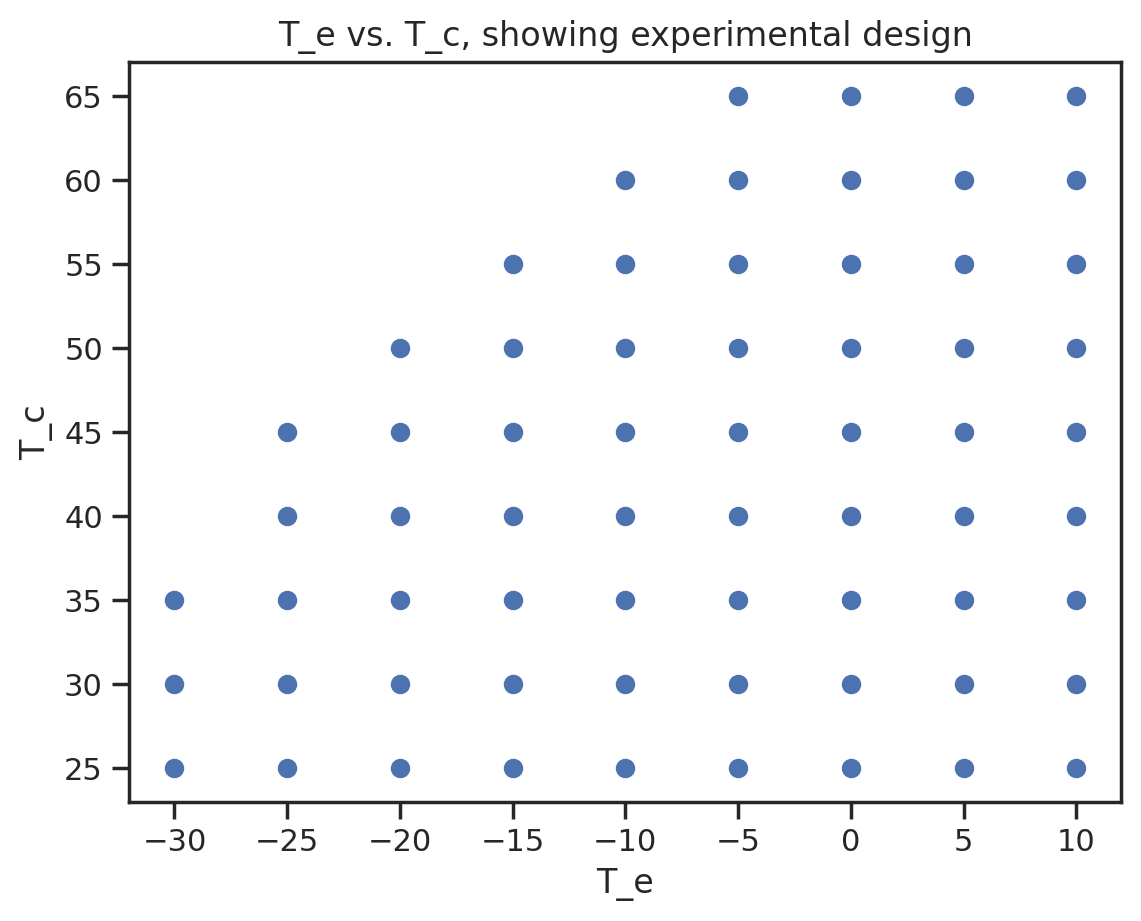

In [8]:
# your code here
import pandas as pd
df = pd.read_excel("compressor_data.xlsx")
plt.scatter(df["T_e"],df["T_c"])
plt.xlabel("T_e")
plt.ylabel("T_c")
plt.title("T_e vs. T_c, showing experimental design")
plt.show()


+ Is there a gap in the experimental design? If yes, why do you think they have a gap?

Yes, there is a gap. Not all T_c temperatures are tested with T_e temperatures on the lower end(T_e<-5 degrees C). This might be because the compressor will never reach those specific combinations of temperatures, so there isn't a reason to test them together.

+ Do the scatter plot between `T_e` and `Capacity`.

Text(0.5, 1.0, 'T_e vs. Capacity')

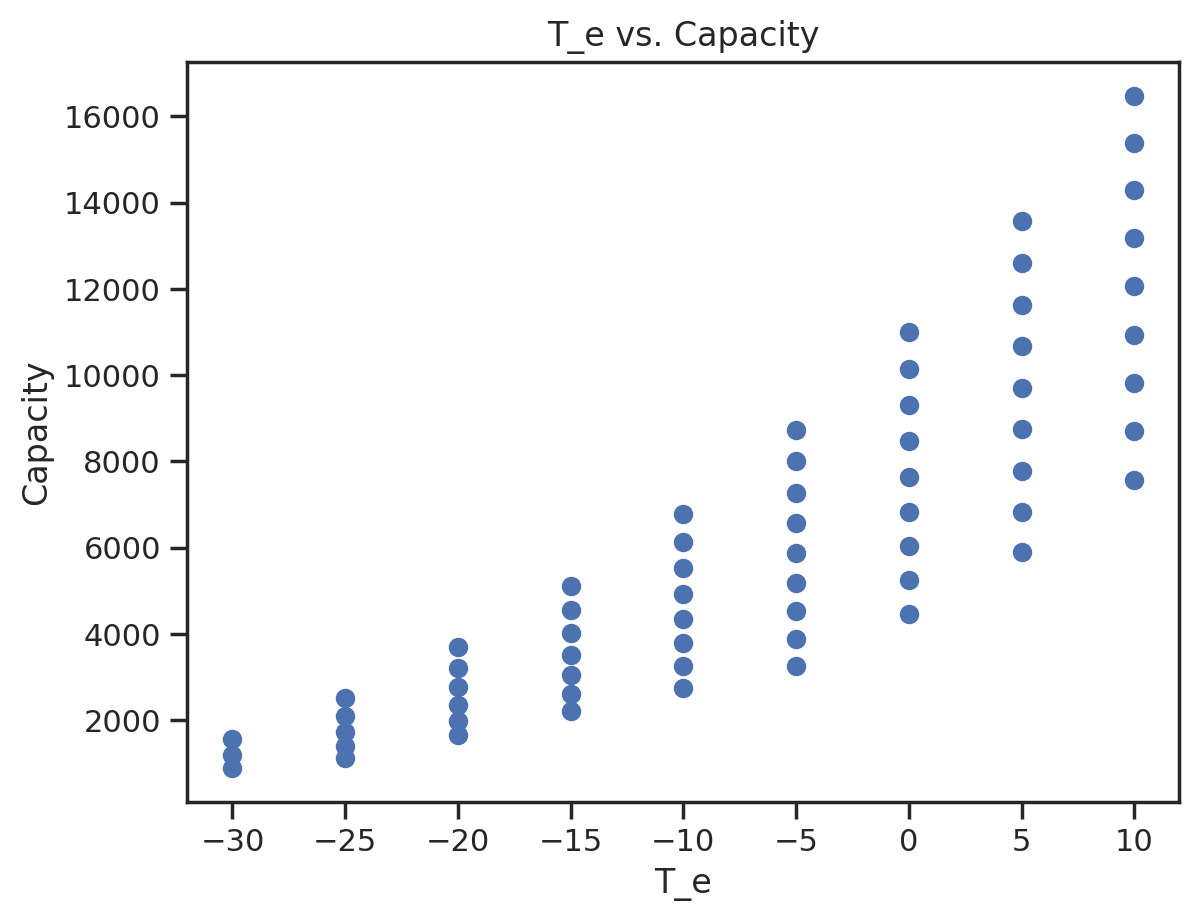

In [14]:
# your code here
plt.scatter(df["T_e"],df["Capacity"])
plt.xlabel("T_e")
plt.ylabel("Capacity")
plt.title("T_e vs. Capacity")

+ Do the scatter plot between `T_c` and `Capacity`.

Text(0.5, 1.0, 'T_c vs. Capacity')

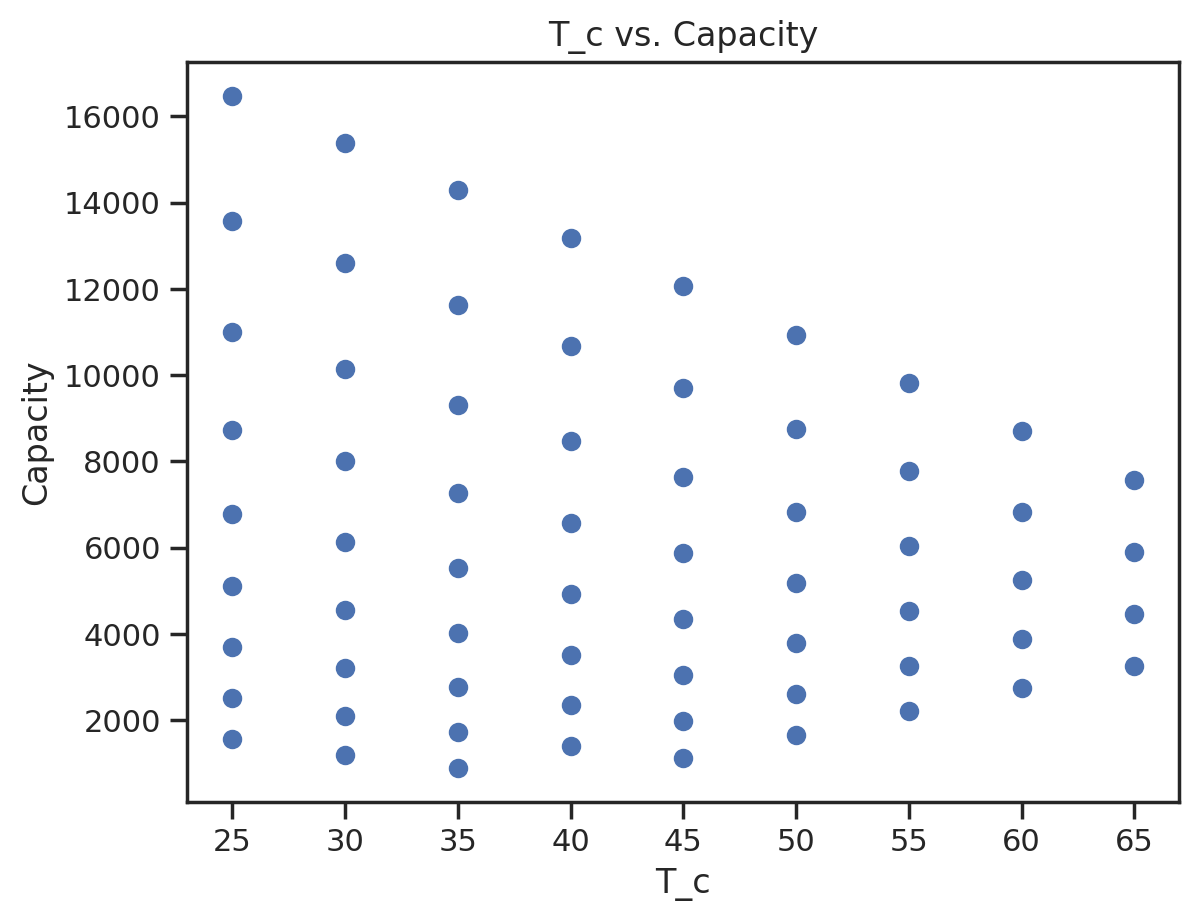

In [15]:
# your code here
plt.scatter(df["T_c"],df["Capacity"])
plt.xlabel("T_c")
plt.ylabel("Capacity")
plt.title("T_c vs. Capacity")

+ Do the scatter plot between `T_e` and `Power`.

Text(0.5, 1.0, 'T_e vs. Power')

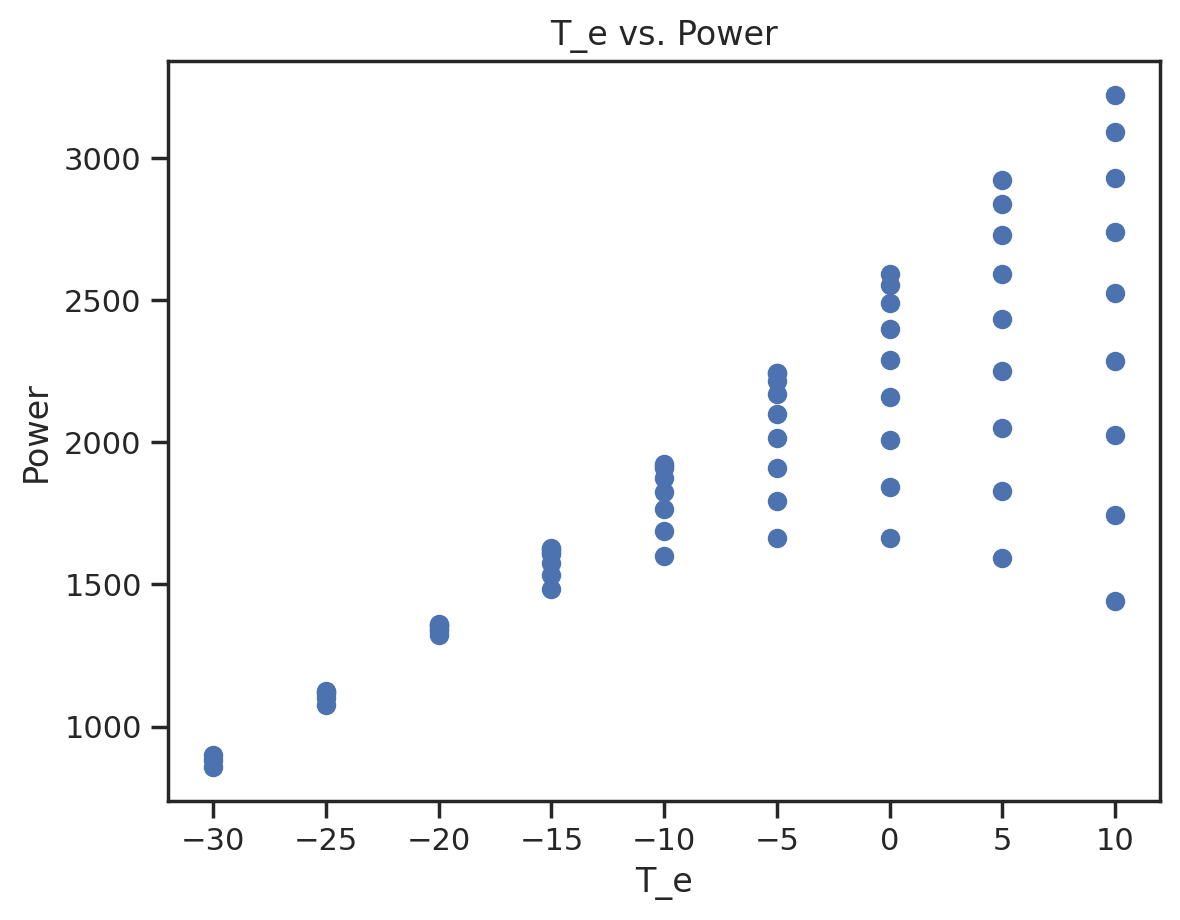

In [16]:
# your code here
plt.scatter(df["T_e"],df["Power"])
plt.xlabel("T_e")
plt.ylabel("Power")
plt.title("T_e vs. Power")

+ Do the scatter plot between `T_c` and `Power`.

Text(0.5, 1.0, 'T_c vs. Power')

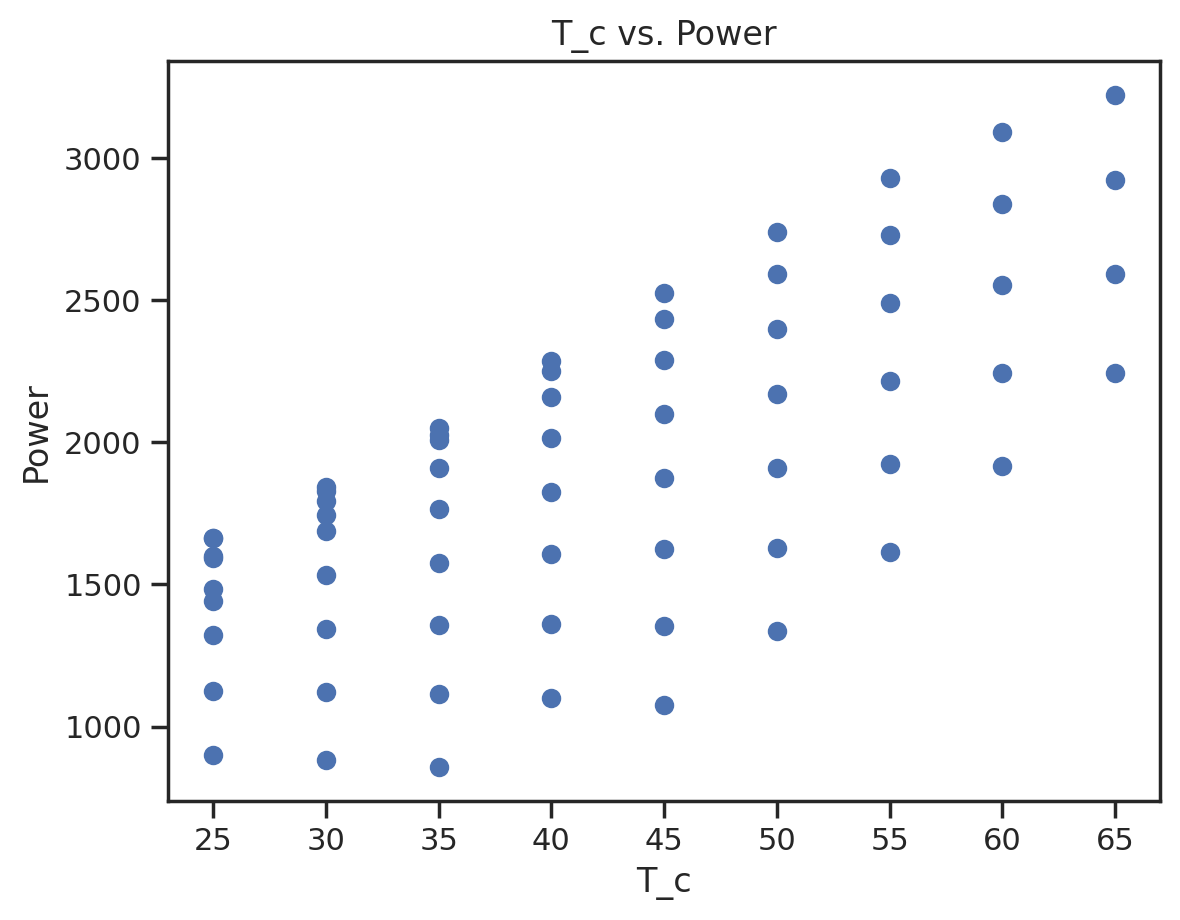

In [17]:
# your code here
plt.scatter(df["T_c"],df["Power"])
plt.xlabel("T_c")
plt.ylabel("Power")
plt.title("T_c vs. Power")

+ We are lucky that we only have two experimental control variables because can do a bit more thing with scatter. You can color each point in the scatter plot according to a scale that follows an output variable. Let me show you what I mean by doing the plot for the `Capacity`.

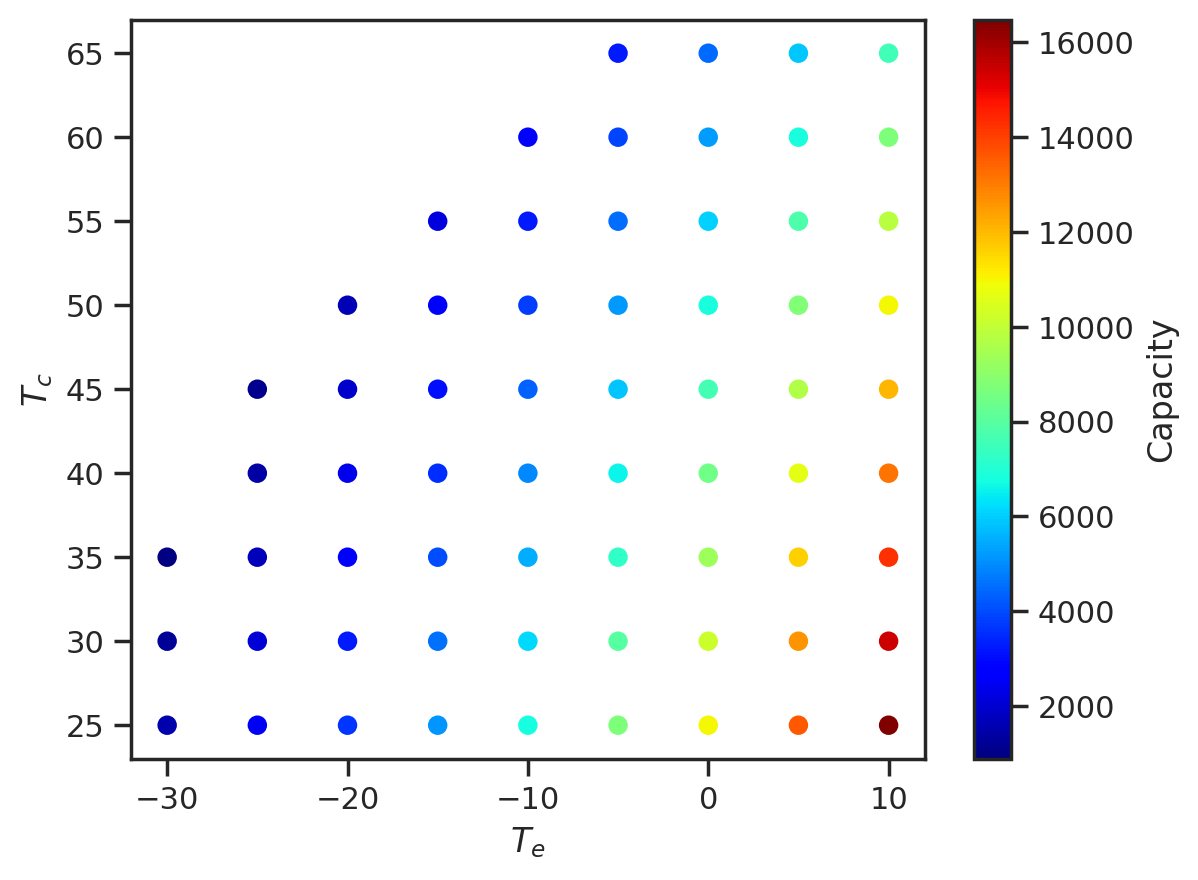

In [19]:
from matplotlib import cm
fig, ax = plt.subplots()
cs = ax.scatter(df['T_e'], df['T_c'], # So far a standard scatter plot
                c=df['Capacity'], # This is telling matplotlib what the color
                                 # of the points should be
                cmap=cm.jet      # This is saying to use the jet colormap
                                 # (blue = smallest values, red = highest values)
               )
plt.colorbar(cs, label='Capacity')   # This gives us a colorbar
ax.set_xlabel('$T_e$')
ax.set_ylabel('$T_c$');

Now repeat the same thing for the `Power`:

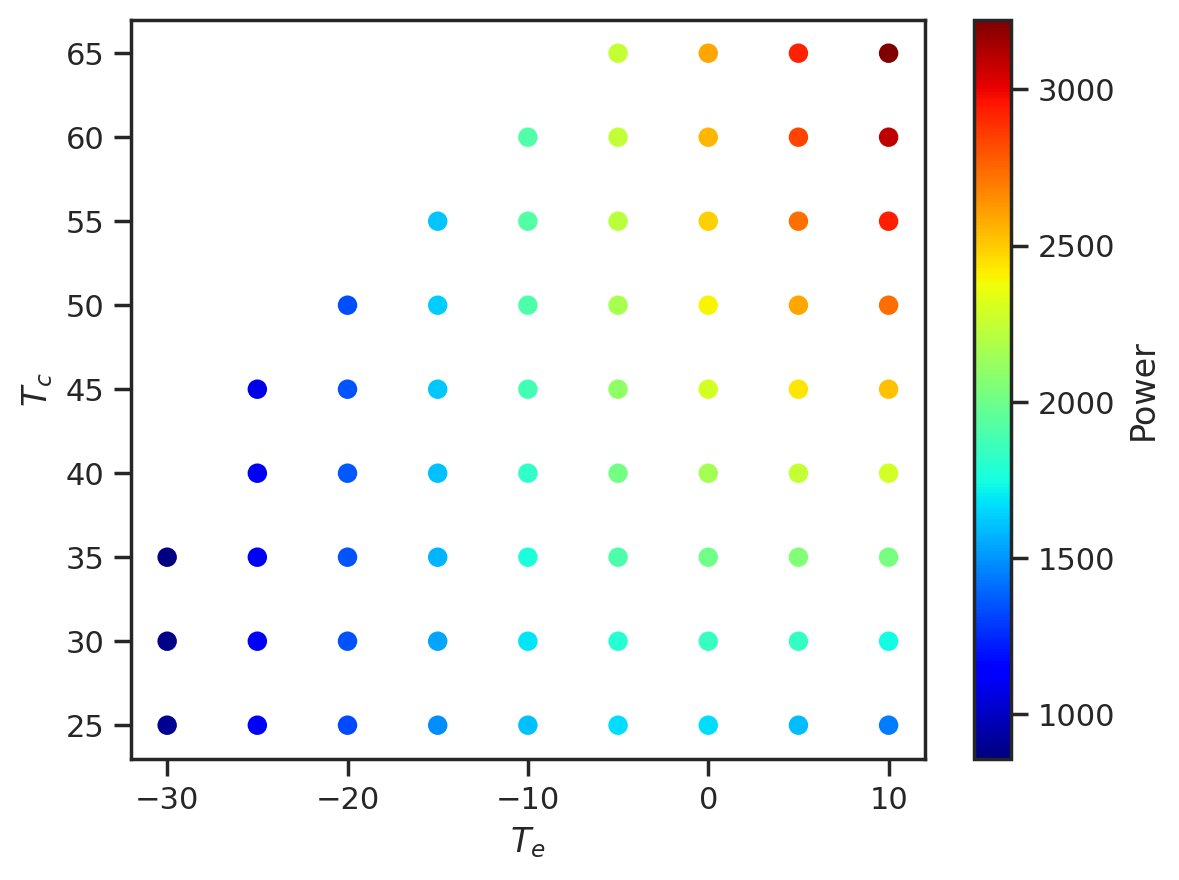

In [20]:
# your code here
fig, ax = plt.subplots()
cs = ax.scatter(df['T_e'], df['T_c'], # So far a standard scatter plot
                c=df['Power'], # This is telling matplotlib what the color
                                 # of the points should be
                cmap=cm.jet      # This is saying to use the jet colormap
                                 # (blue = smallest values, red = highest values)
               )
plt.colorbar(cs, label='Power')   # This gives us a colorbar
ax.set_xlabel('$T_e$')
ax.set_ylabel('$T_c$');

## Problem 2 - Visual analysis of an airfoil experiment

In this problem, you are going to repeat what you did in Problem 1, but without my guidance!

The dataset we are going to use is the [Airfoil Self-Noise Data Set](https://archive.ics.uci.edu/dataset/291/airfoil+self+noise)
From this reference, the descreption of the dataset is as follows:

> The NASA data set comprises different size NACA 0012 airfoils at various wind tunnel speeds and angles of attack. The span of the airfoil and the observer position were the same in all of the experiments.
>
> Attribute Information:
> This problem has the following inputs:
> 1. Frequency, in Hertzs.
> 2. Angle of attack, in degrees.
> 3. Chord length, in meters.
> 4. Free-stream velocity, in meters per second.
> 5. Suction side displacement thickness, in meters.

> The only output is:
> 6. Scaled sound pressure level, in decibels.

Before we start, let's download and load the data.
I am going to put them in a dataframe for you.

In [21]:
!curl -O 'https://archive.ics.uci.edu/ml/machine-learning-databases/00291/airfoil_self_noise.dat'
import numpy as np
import pandas as pd
raw_data = np.loadtxt('airfoil_self_noise.dat')
df = pd.DataFrame(raw_data,
                  columns=['Frequency', 'Angle_of_attack', 'Chord_length',
                            'Velocity', 'Suction_thickness', 'Sound_pressure'])
df

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 59984    0 59984    0     0  30771      0 --:--:--  0:00:01 --:--:-- 30761


,Frequency,Angle_of_attack,Chord_length,Velocity,Suction_thickness,Sound_pressure
0,800.0,0.0,0.3048,71.3,0.002663,126.201
1,1000.0,0.0,0.3048,71.3,0.002663,125.201
2,1250.0,0.0,0.3048,71.3,0.002663,125.951
3,1600.0,0.0,0.3048,71.3,0.002663,127.591
4,2000.0,0.0,0.3048,71.3,0.002663,127.461
...,...,...,...,...,...,...
1498,2500.0,15.6,0.1016,39.6,0.052849,110.264
1499,3150.0,15.6,0.1016,39.6,0.052849,109.254
1500,4000.0,15.6,0.1016,39.6,0.052849,106.604
1501,5000.0,15.6,0.1016,39.6,0.052849,106.224


+ Do the histogtrams of all variables. Use as many code segments you need below to plot the histogram of each variable in a different plot. Make sure you label the axes correctly.

Text(0.5, 0, 'Frequency')

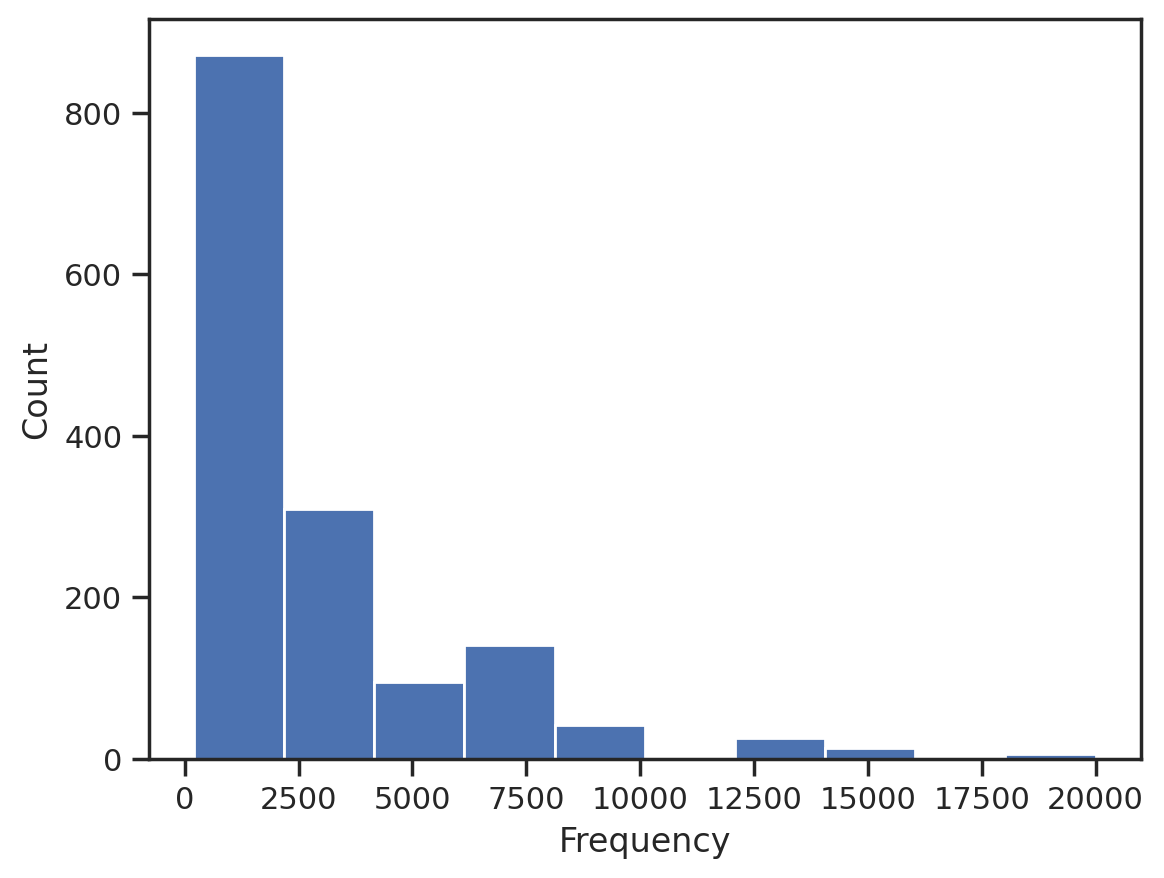

In [39]:
# your code here (as many blocks as you like)
plt.hist(df["Frequency"])
plt.ylabel("Count")
plt.xlabel("Frequency")

Text(0.5, 0, 'Angle_of_attack')

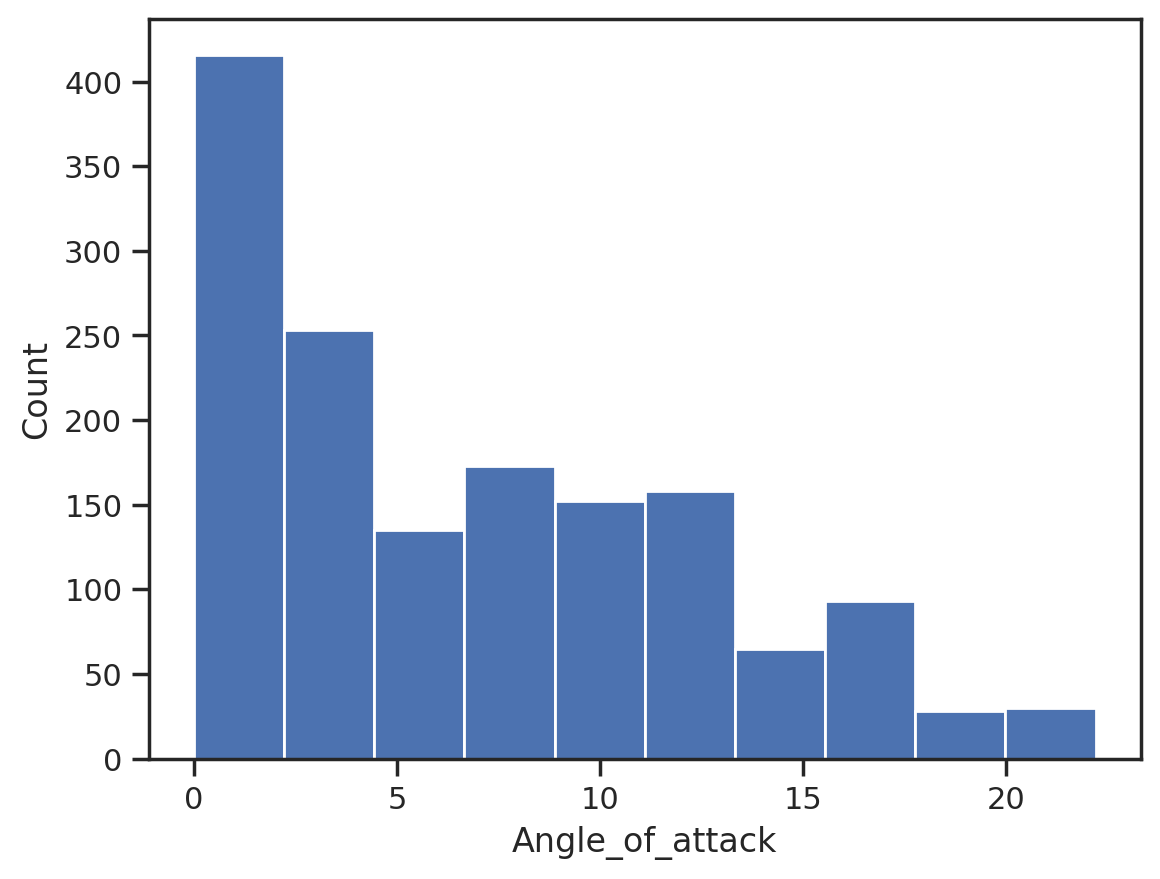

In [40]:
plt.hist(df["Angle_of_attack"])
plt.ylabel("Count")
plt.xlabel("Angle_of_attack")

Text(0, 0.5, 'Count')

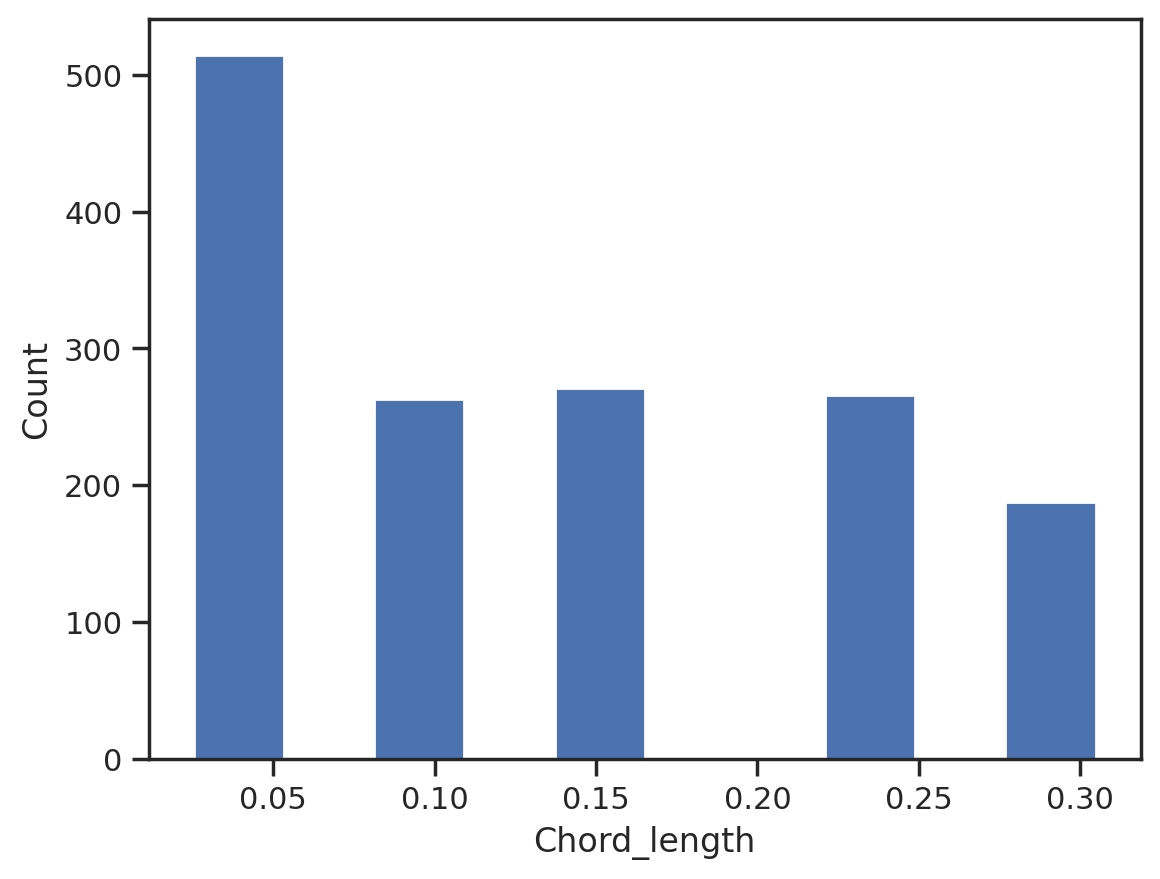

In [41]:
plt.hist(df["Chord_length"])
plt.xlabel("Chord_length")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

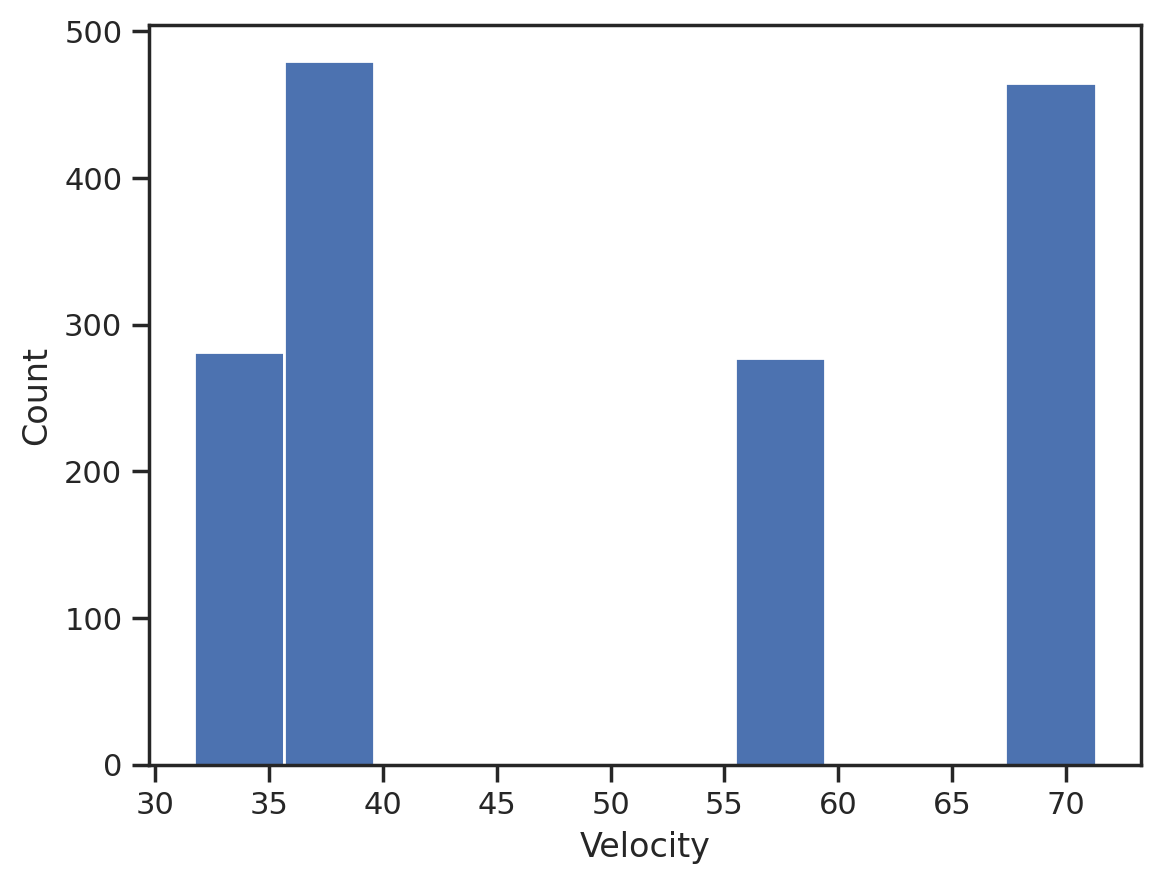

In [42]:
plt.hist(df["Velocity"])
plt.xlabel("Velocity")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

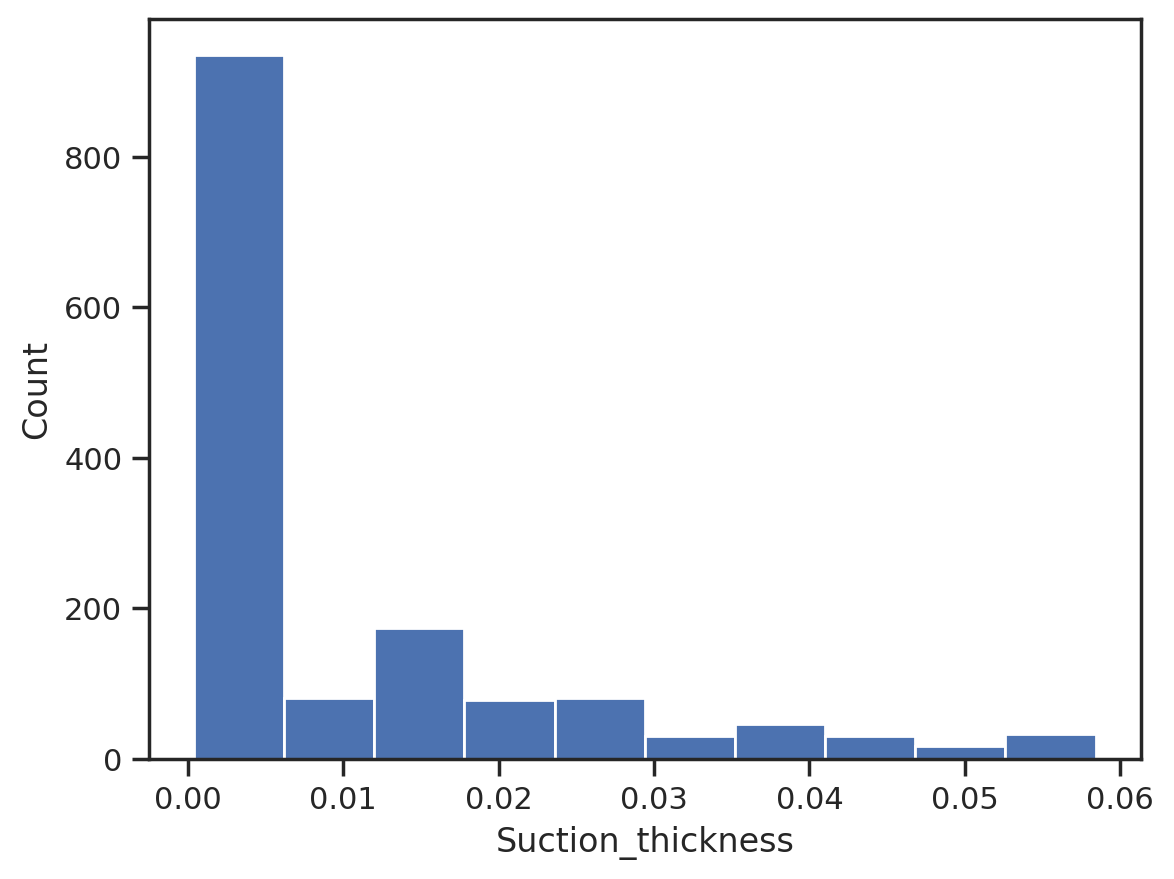

In [43]:
plt.hist(df["Suction_thickness"])
plt.xlabel("Suction_thickness")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

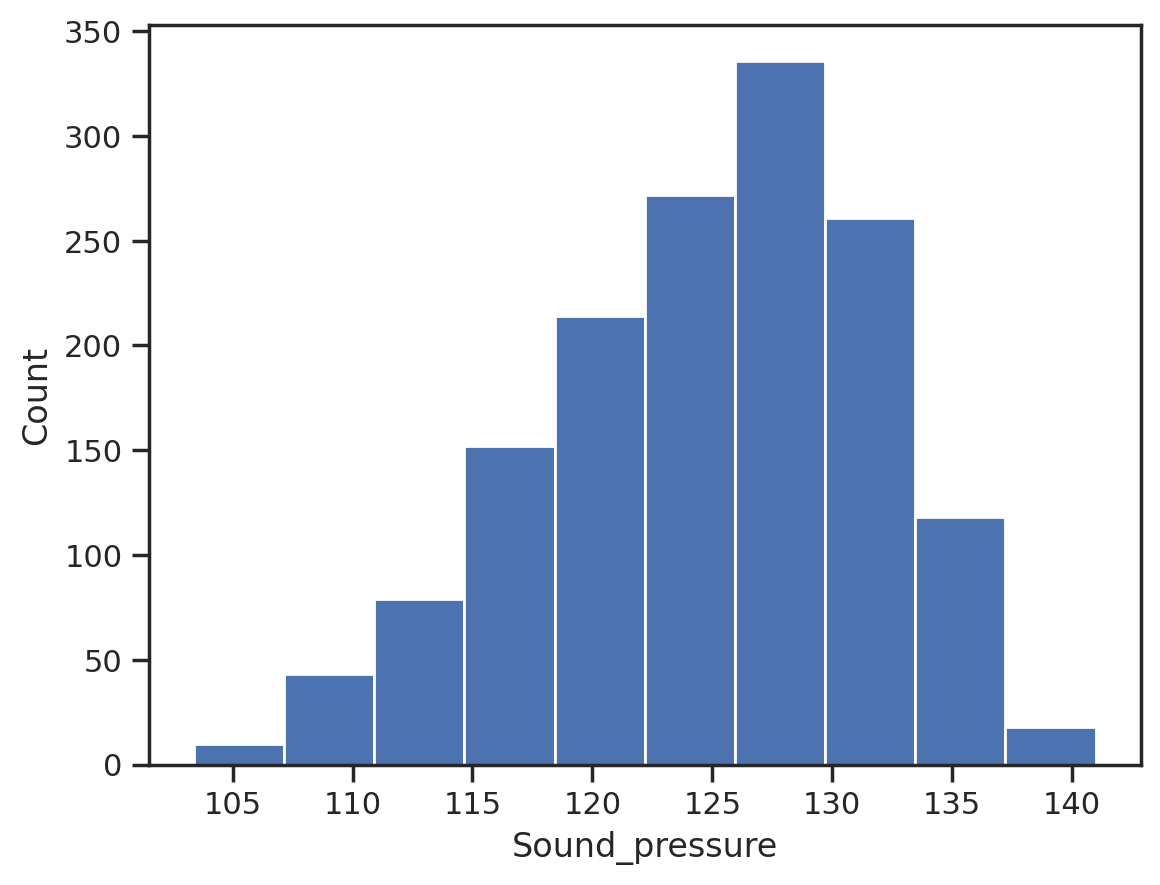

In [44]:
plt.hist(df["Sound_pressure"])
plt.xlabel("Sound_pressure")
plt.ylabel("Count")

:+ Do the scatter plot between all input variables. This will give you an idea of the range of experimental conditions. Are there any holes in the experimental dataset, i.e., places where you have no data?

Text(0, 0.5, 'Angle_of_Attack')

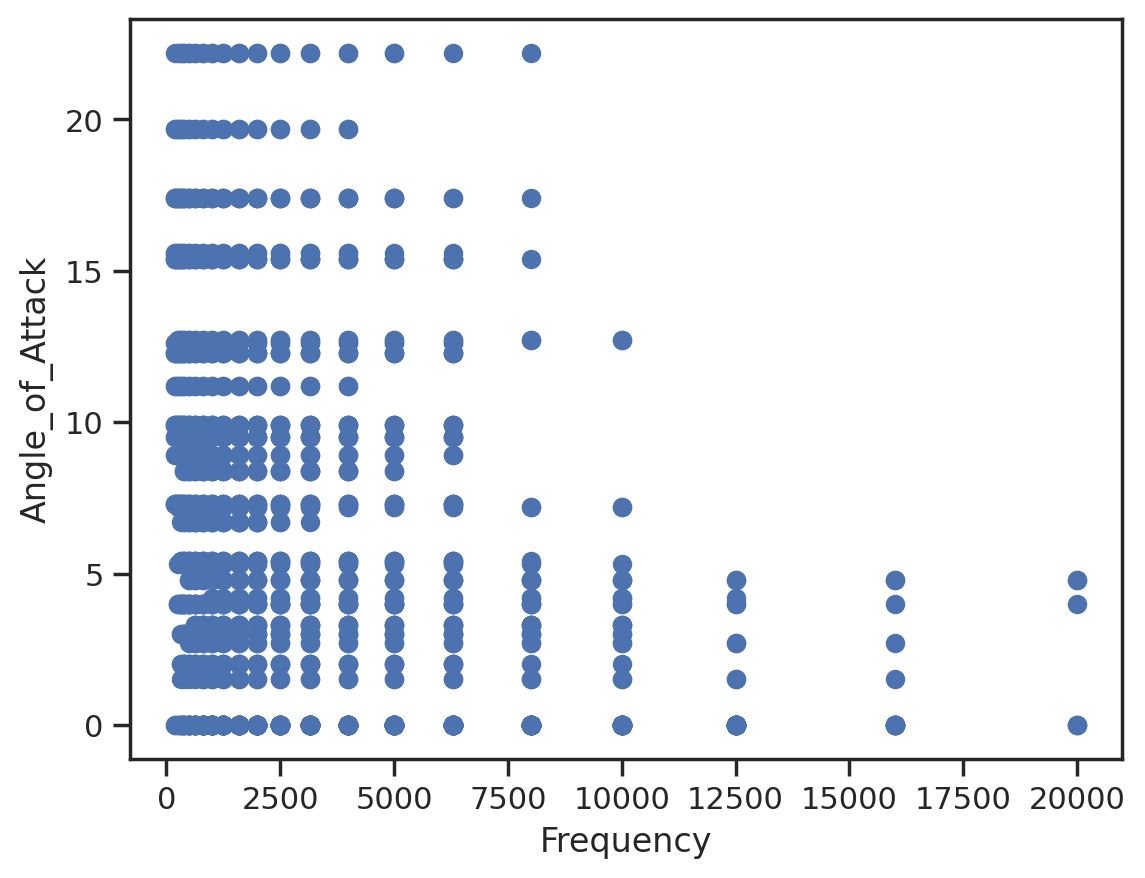

In [38]:
# your code here (as many blocks as you like)
plt.scatter(df['Frequency'],df['Angle_of_attack'])
plt.xlabel("Frequency")
plt.ylabel("Angle_of_Attack")

Text(0, 0.5, 'Chord_length')

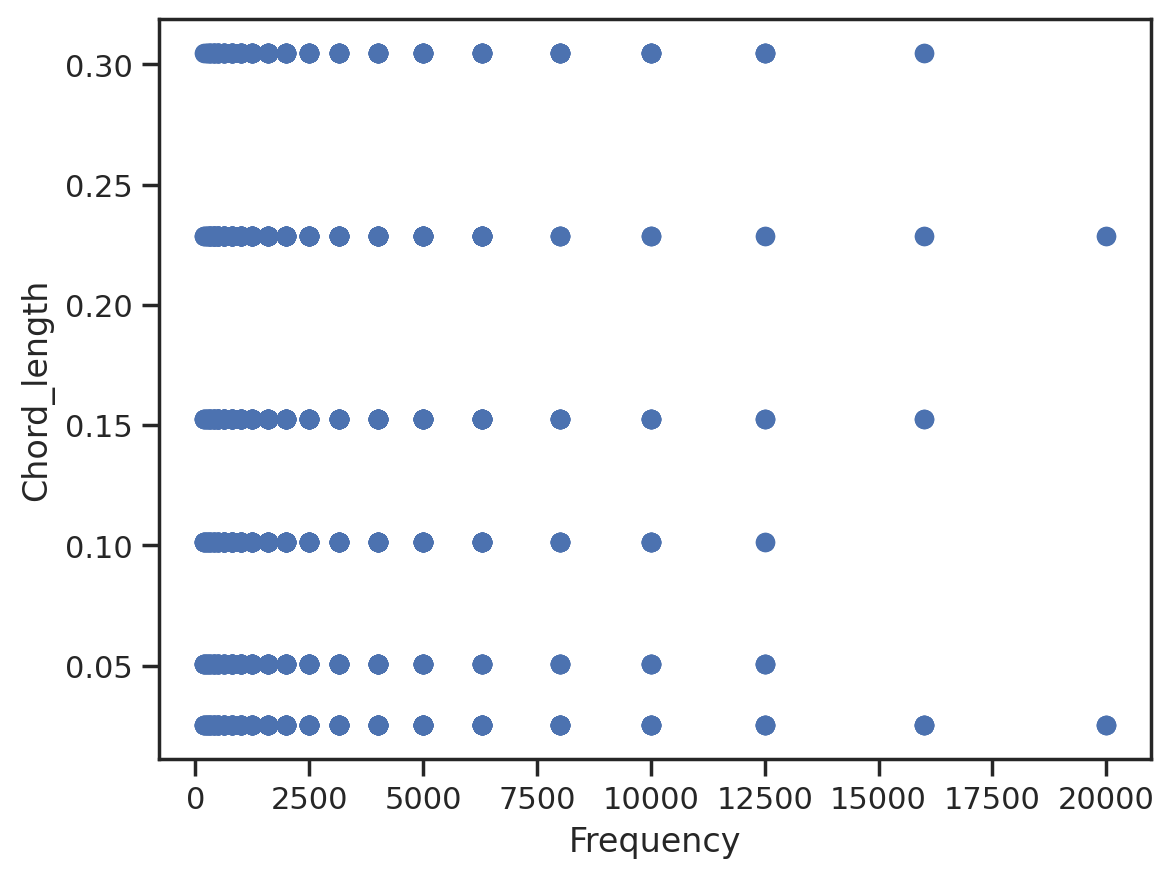

In [45]:
plt.scatter(df['Frequency'],df['Chord_length'])
plt.xlabel("Frequency")
plt.ylabel("Chord_length")

Text(0, 0.5, 'Velocity')

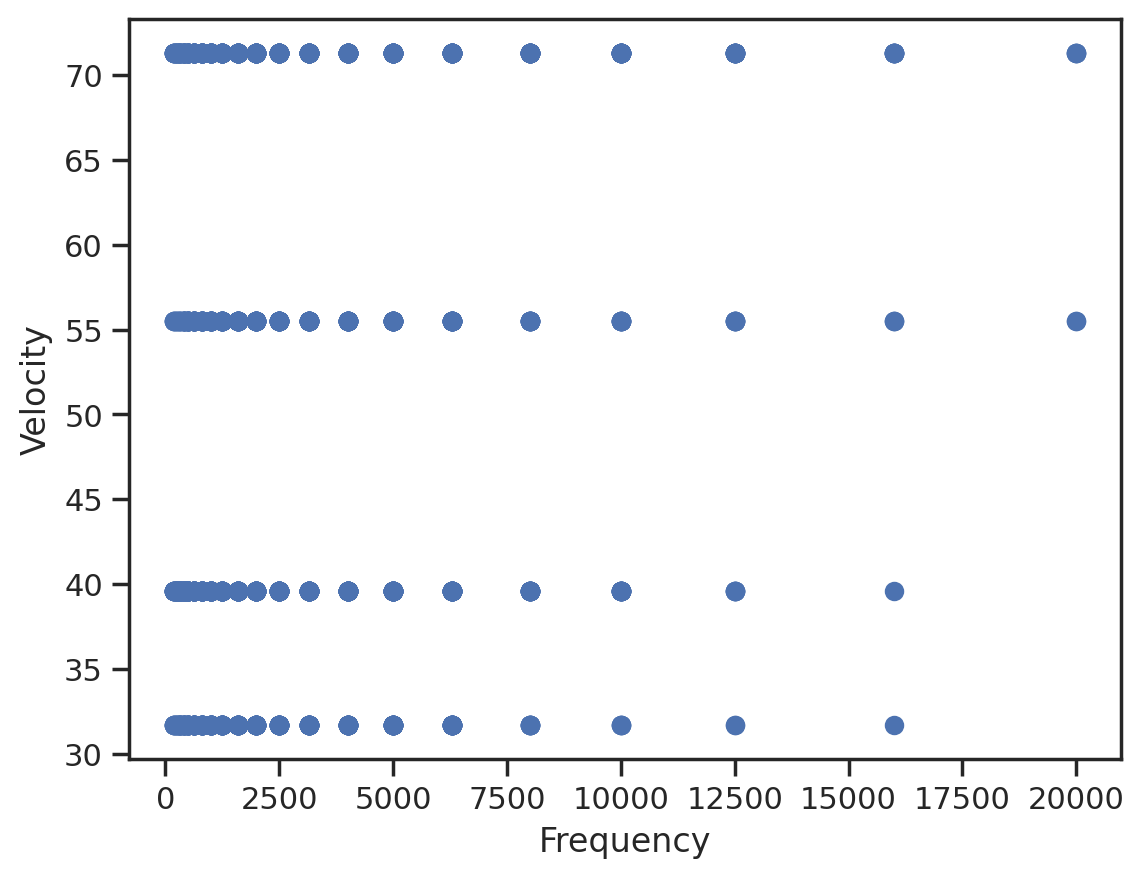

In [46]:
plt.scatter(df['Frequency'],df['Velocity'])
plt.xlabel("Frequency")
plt.ylabel("Velocity")

Text(0, 0.5, 'Suction_thickness')

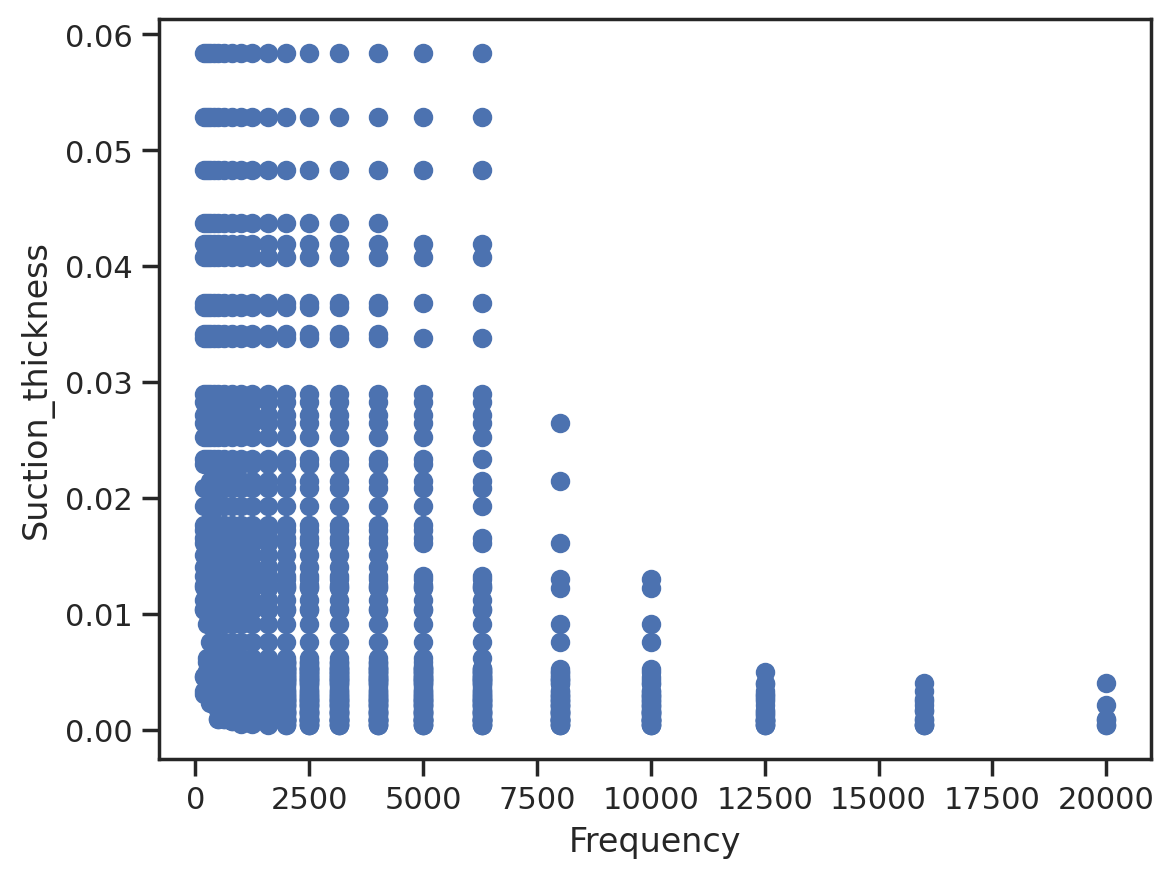

In [47]:
plt.scatter(df['Frequency'],df['Suction_thickness'])
plt.xlabel("Frequency")
plt.ylabel("Suction_thickness")

Text(0, 0.5, 'Chord_length')

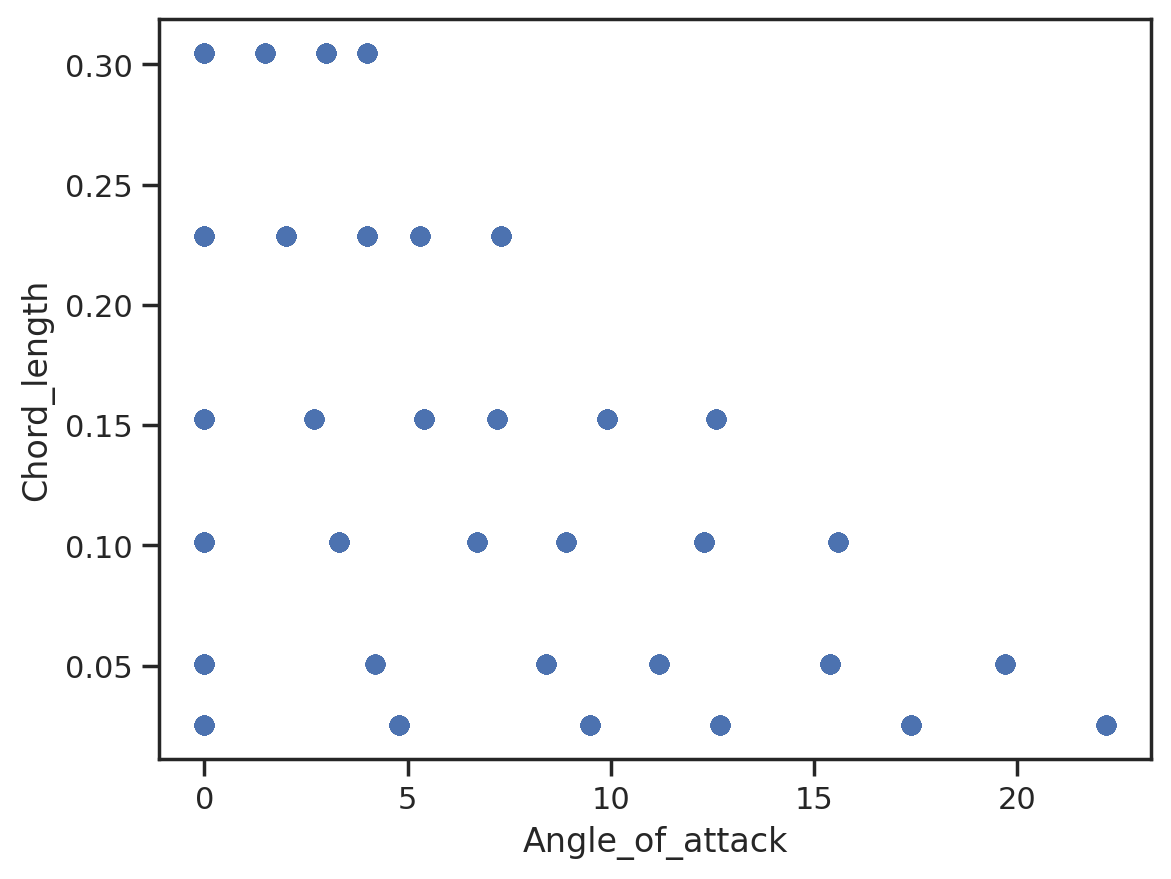

In [48]:
plt.scatter(df['Angle_of_attack'],df['Chord_length'])
plt.xlabel("Angle_of_attack")
plt.ylabel("Chord_length")

Text(0, 0.5, 'Velocity')

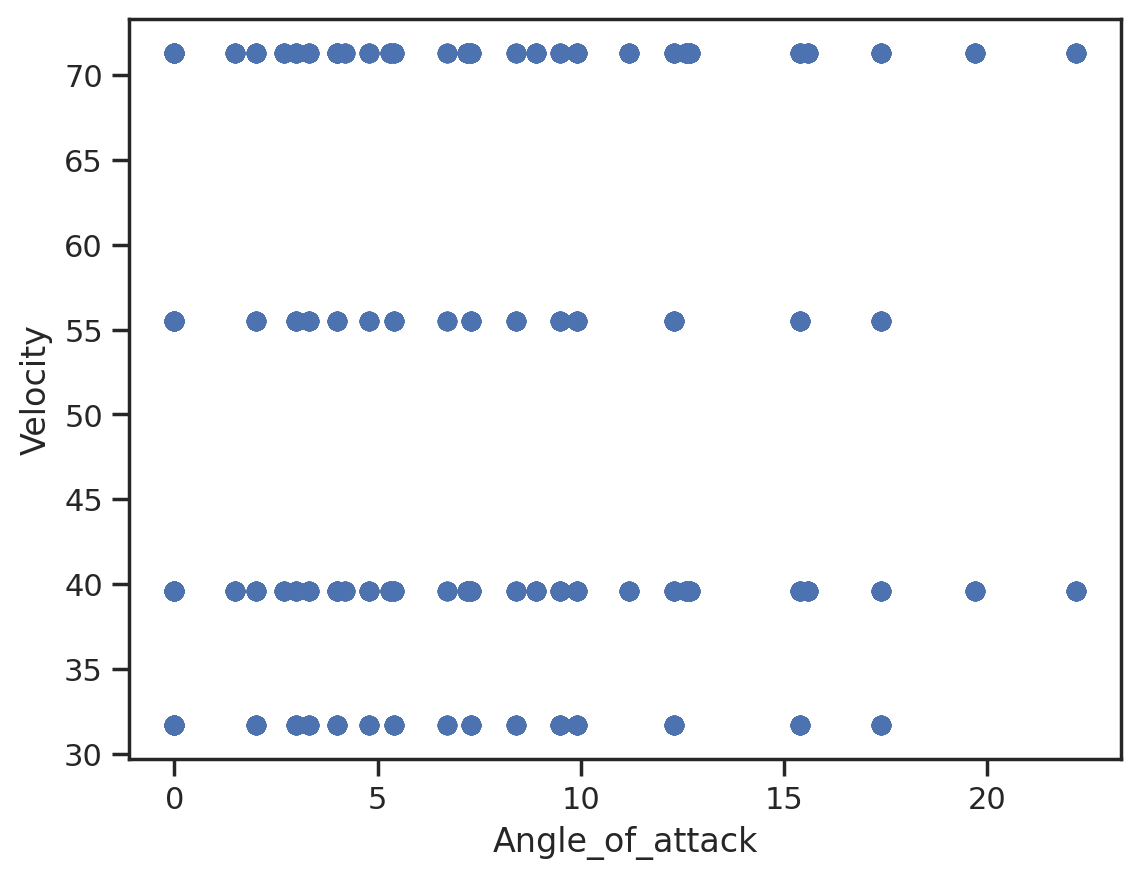

In [49]:
plt.scatter(df['Angle_of_attack'],df['Velocity'])
plt.xlabel("Angle_of_attack")
plt.ylabel("Velocity")

Text(0, 0.5, 'Suction_thickness')

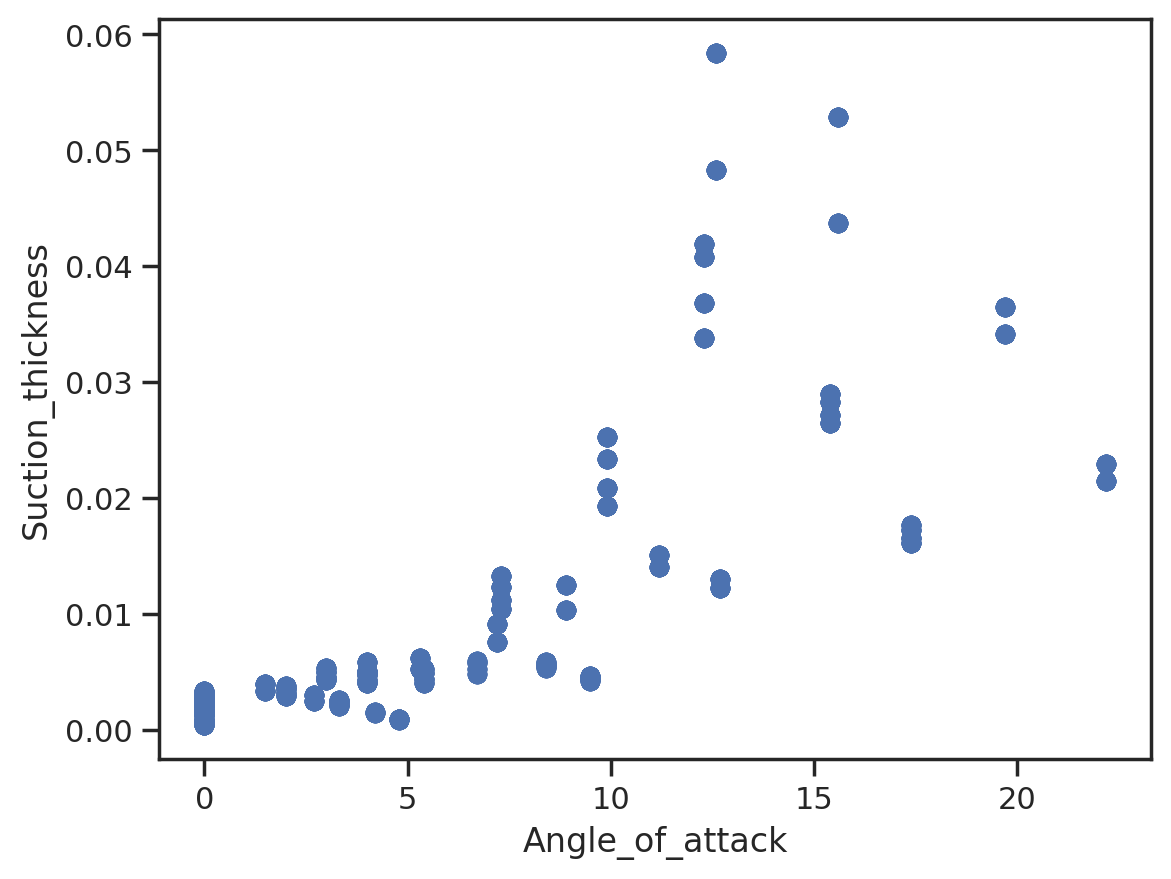

In [50]:
plt.scatter(df['Angle_of_attack'],df['Suction_thickness'])
plt.xlabel("Angle_of_attack")
plt.ylabel("Suction_thickness")

Text(0, 0.5, 'Velocity')

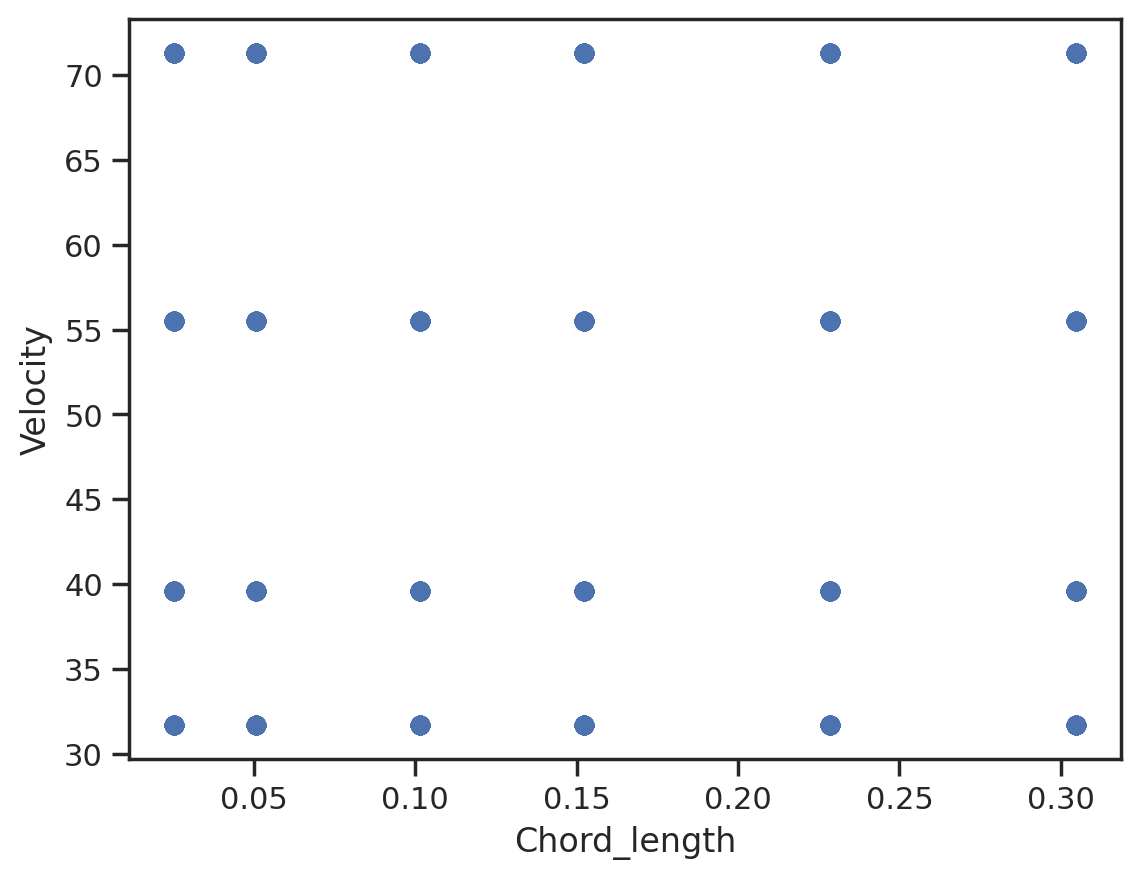

In [51]:
plt.scatter(df['Chord_length'],df['Velocity'])
plt.xlabel("Chord_length")
plt.ylabel("Velocity")

Text(0, 0.5, 'Suction_thickness')

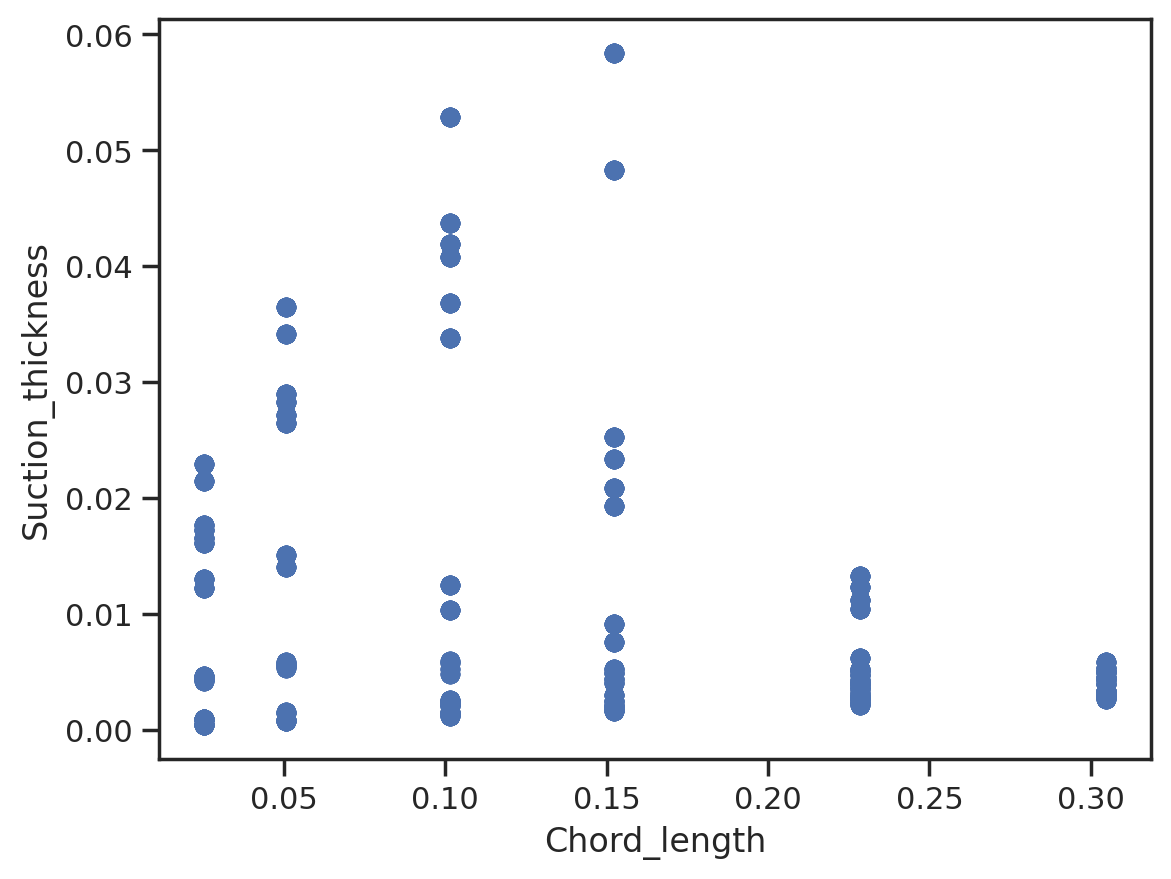

In [52]:
plt.scatter(df['Chord_length'],df['Suction_thickness'])
plt.xlabel("Chord_length")
plt.ylabel("Suction_thickness")

Text(0, 0.5, 'Suction_thickness')

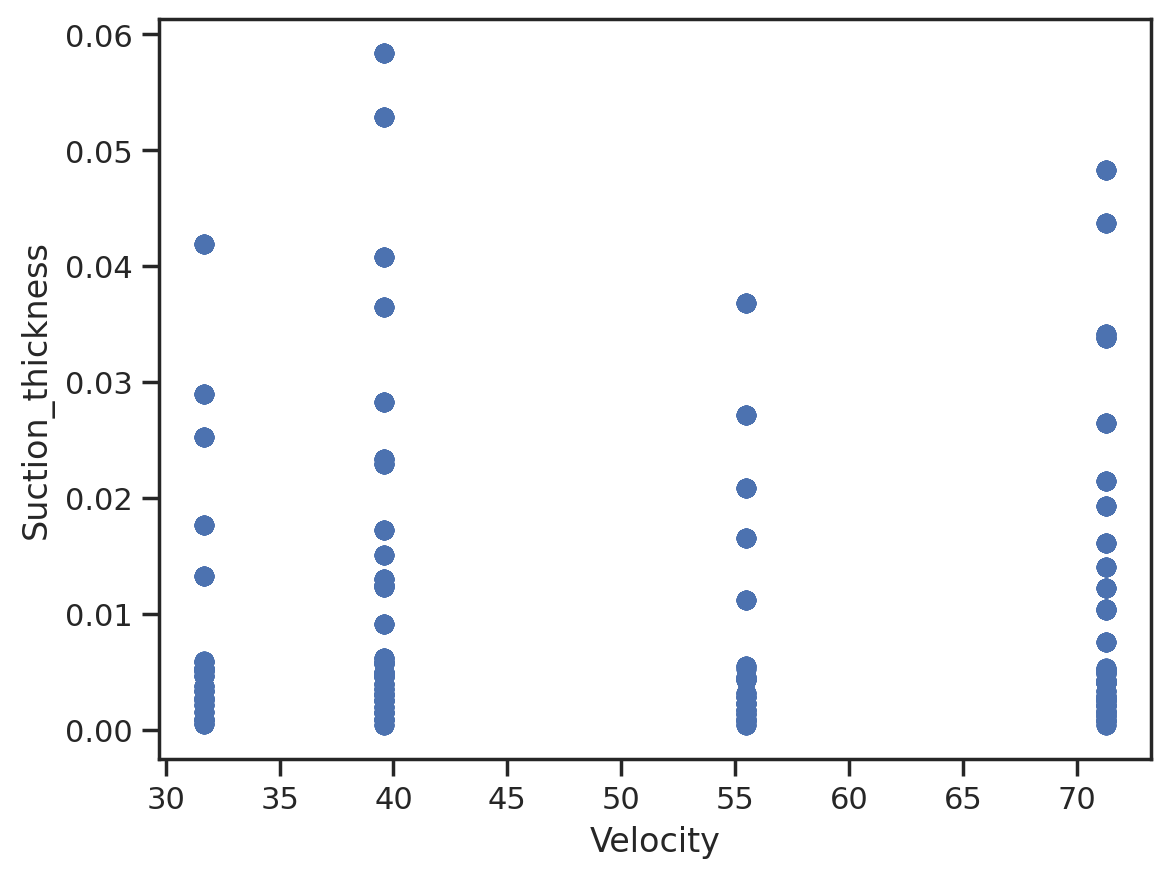

In [53]:
plt.scatter(df['Velocity'],df['Suction_thickness'])
plt.xlabel("Velocity")
plt.ylabel("Suction_thickness")

*Your explanation here*:


*   All tested levels of **frequency** are tested against the full range of the other input variables with these exceptions: Higher ranges of frequency are not tested with higher angles of attack, nor higher suction thicknesses.
*   All tested **angles of attack** are tested against the full range of the other input variables, with these exceptions:
Higher angles of attack are not tested with higher chord lengths, higher frequencies, nor with lower suction thicknesses.
*   All tested **chord_length** are tested against the full range of the other input variables, with these exceptions:
Larger chord lengths are not tested with larger suction thicknesses nor larger angles of attack.
*    All tested **velocities** are tested against the full range of the other input variables.
*    All tested **suction thicknesses** are tested against the full range of the other input variables, with these exceptions: Larger suction thicknesses are not tested with  higher frequencies nor larger chord lengths, and smaller suction thicknesses are not tested against higher angles of attack.

This shows the gaps in the data that may make it difficult to predict the output varible when testing in those ranges.

+  Do the scatter plot between each input variable and the output. This will give you an idea of the relationship between each input and the output. Do you observe any obvious patterns?

Text(0, 0.5, 'Sound Pressure')

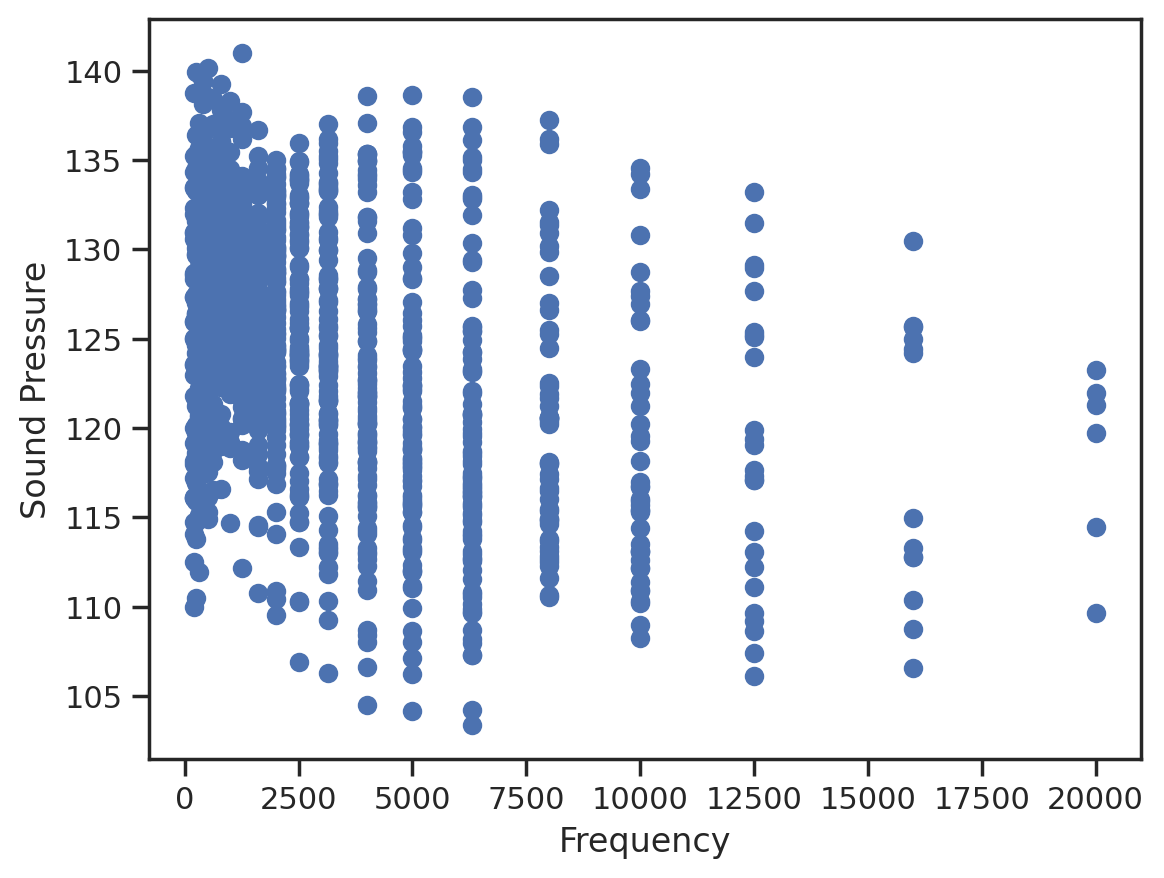

In [54]:
# your code here (as many blocks as you like)
plt.scatter(df["Frequency"],df['Sound_pressure'])
plt.xlabel("Frequency")
plt.ylabel("Sound Pressure")

Text(0, 0.5, 'Sound Pressure')

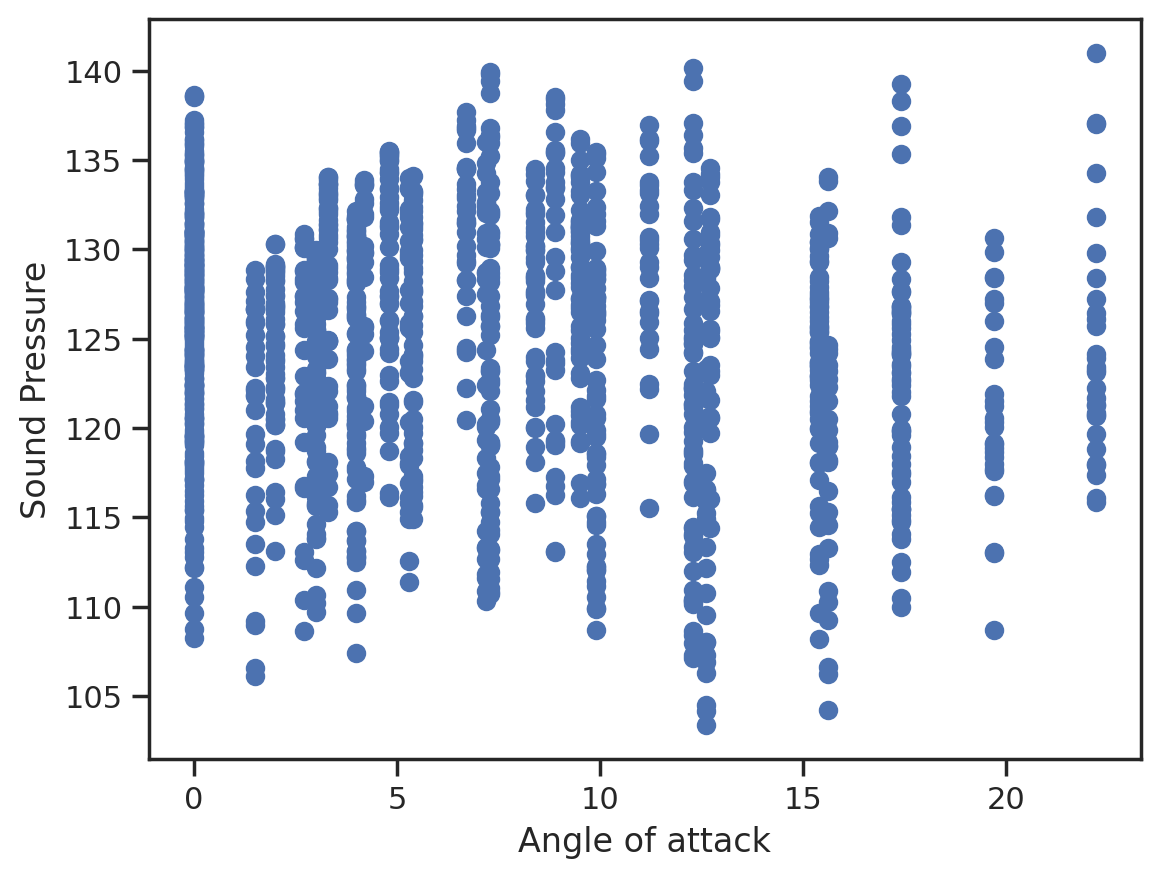

In [55]:
plt.scatter(df["Angle_of_attack"],df['Sound_pressure'])
plt.xlabel("Angle of attack")
plt.ylabel("Sound Pressure")

Text(0, 0.5, 'Sound Pressure')

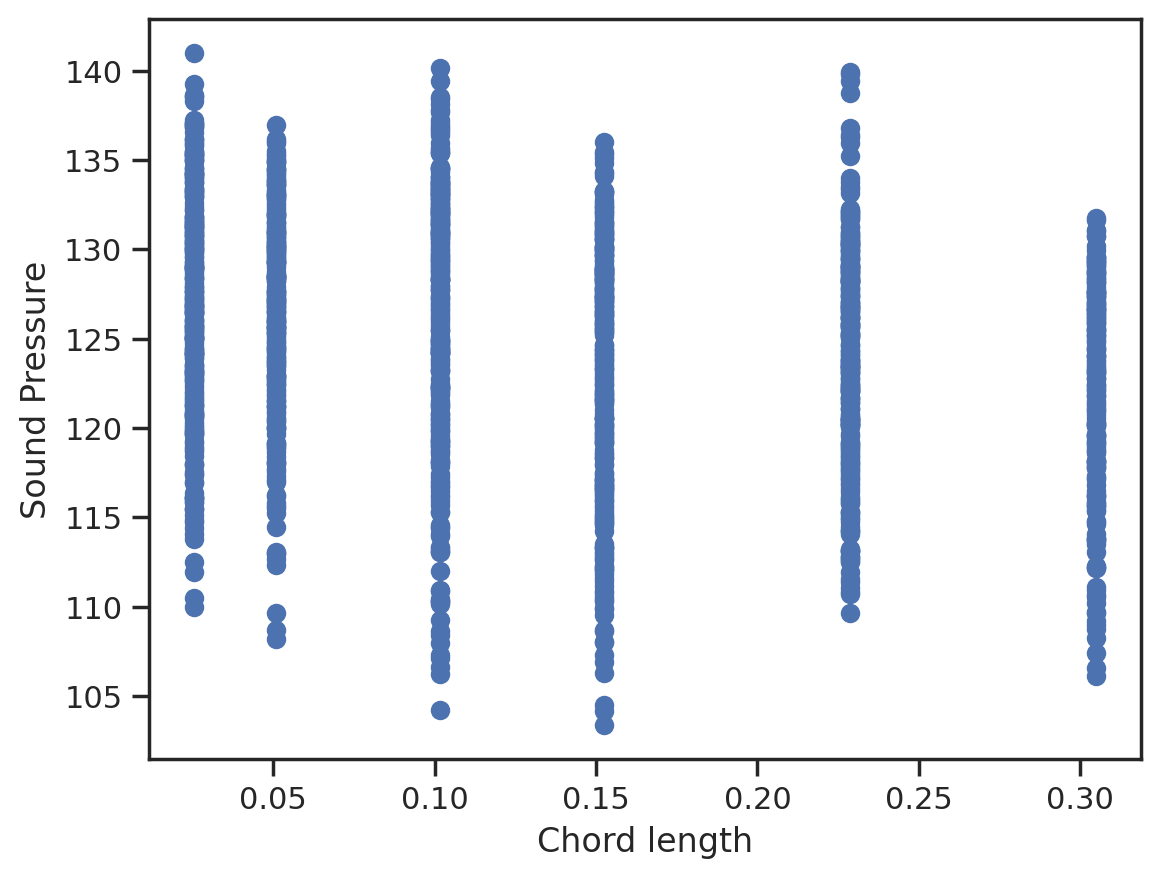

In [57]:
plt.scatter(df["Chord_length"],df['Sound_pressure'])
plt.xlabel("Chord length")
plt.ylabel("Sound Pressure")

Text(0, 0.5, 'Sound Pressure')

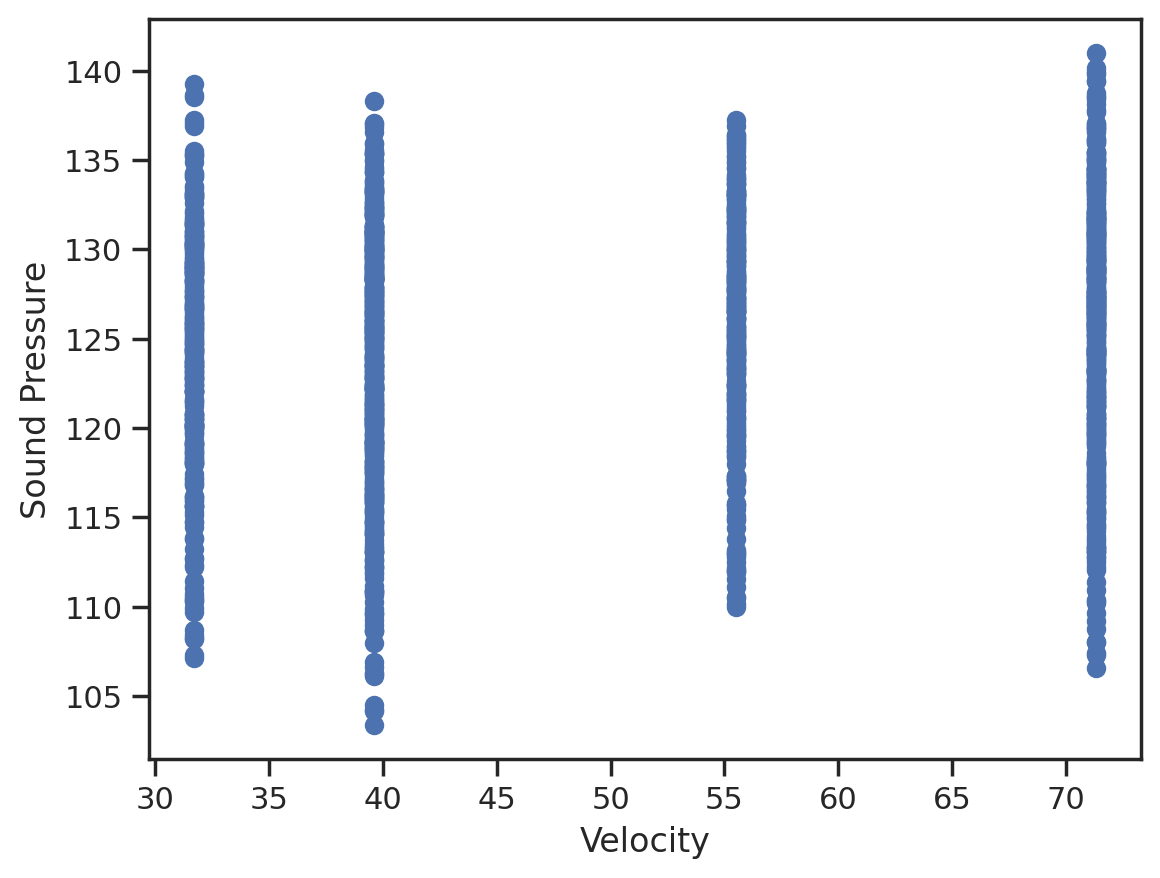

In [58]:
plt.scatter(df["Velocity"],df['Sound_pressure'])
plt.xlabel("Velocity")
plt.ylabel("Sound Pressure")

Text(0, 0.5, 'Sound Pressure')

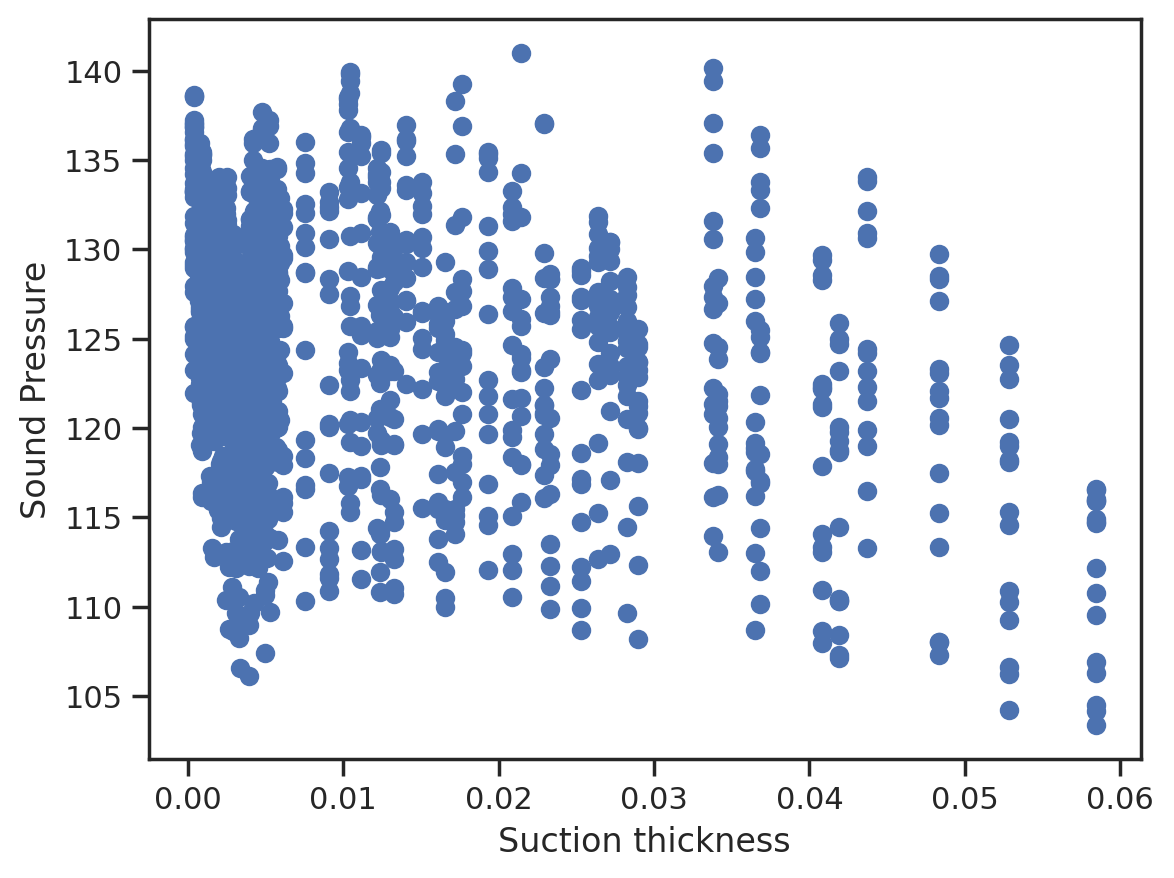

In [59]:
plt.scatter(df["Suction_thickness"],df['Sound_pressure'])
plt.xlabel("Suction thickness")
plt.ylabel("Sound Pressure")

*Your explanation here* - It seems like there isn't one variable that has a greater effect on the sound pressure than the others because the range of each input variable is associated with a consistent range of sound pressures. What this means in practice is that you could pick any (tested) value of any of the input values, and achieve any desired value of sound pressure (between ~105 and ~140 decibels) by adjusting the other four input variables.

+ Now pick the two input variables you think are the most important and do the scatter plot between them using the output to color the points (see the last question of Problem 1). Feel free to repeat it with more than two pairs of inputs if you want. Briefly discuss your findings.

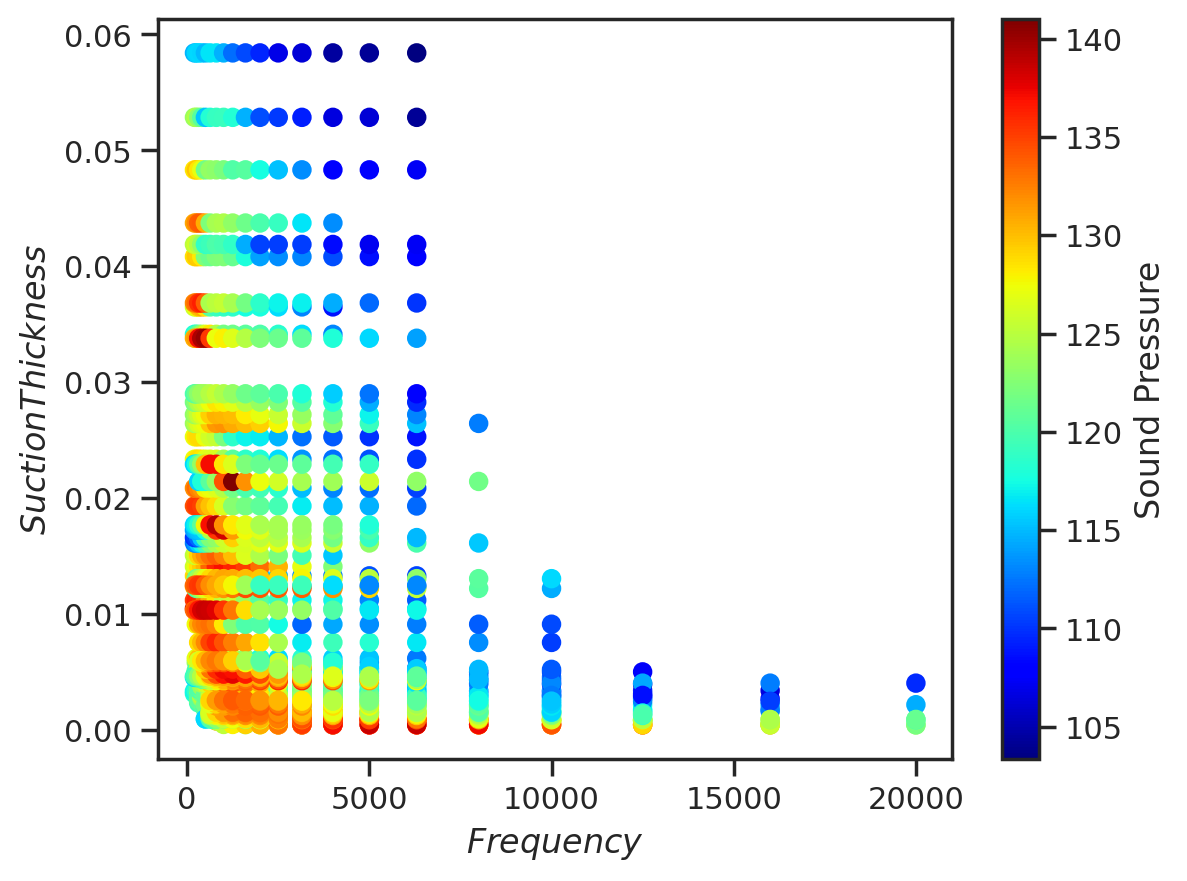

In [63]:
# your code here (as many blocks as you like)
fig, ax = plt.subplots()
cs = ax.scatter(df['Frequency'], df['Suction_thickness'], # So far a standard scatter plot
                c=df['Sound_pressure'], # This is telling matplotlib what the color
                                 # of the points should be
                cmap=cm.jet      # This is saying to use the jet colormap
                                 # (blue = smallest values, red = highest values)
               )
plt.colorbar(cs, label='Sound Pressure')   # This gives us a colorbar
ax.set_xlabel('$Frequency$')
ax.set_ylabel('$Suction Thickness$');

*Your explanation here* - Of the five input variables, the two that have the easiest-to-see correlation between the selected input varible sound pressure are frequency and suction thickness. The colormap confirms that these two variables are a good indicator of sound pressure since tests with lower frequencies AND lower suction thickness are associated with higher sound pressure, as can be seen in the graph.